# 1. Sentetik Halı Görüntüleri (Day 11)
Bu çalışma defteri, Merinos endüstriyel halı dokuma tezgahlarında karşılaşılan yapısal ve yüzey kusurlarının matematiksel morfoloji operatörleri ile incelenmesini ve tespitini gerçekleştirmektedir.

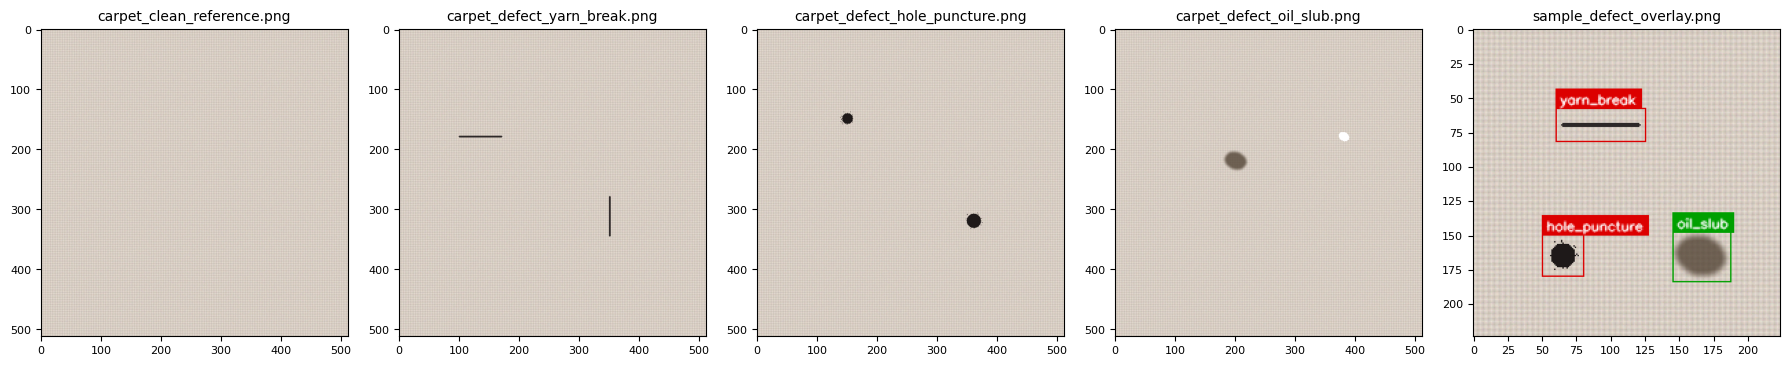

In [1]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Proje ve veri dizinleri dinamik çözümlenmesi
CURRENT_DIR = Path.cwd().resolve()
MINI_PROJECT_DIR = CURRENT_DIR if CURRENT_DIR.name == "mini_project" else CURRENT_DIR / "day11" / "mini_project"
FIXTURES_DIR = MINI_PROJECT_DIR / "fixtures" / "synthetic_carpets"
OUTPUTS_DIR = MINI_PROJECT_DIR / "outputs"

image_files = [
    ("carpet_clean_reference.png", FIXTURES_DIR / "carpet_clean_reference.png"),
    ("carpet_defect_yarn_break.png", FIXTURES_DIR / "carpet_defect_yarn_break.png"),
    ("carpet_defect_hole_puncture.png", FIXTURES_DIR / "carpet_defect_hole_puncture.png"),
    ("carpet_defect_oil_slub.png", FIXTURES_DIR / "carpet_defect_oil_slub.png"),
    ("sample_defect_overlay.png", OUTPUTS_DIR / "sample_defect_overlay.png"),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, (title, fpath) in zip(axes, image_files):
    if fpath.exists():
        raw_data = np.fromfile(str(fpath), dtype=np.uint8)
        img = cv2.imdecode(raw_data, cv2.IMREAD_COLOR)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.show()

## 2. Temel Morfolojik Operatörlerin İncelenmesi (Aşındırma, Genişletme, Açma, Kapama)
`MorphologyEngine` sınıfı kullanılarak delik/delinme kusuru üzerinde temel morfolojik işlemlerin piksel düzeyindeki etkileri:

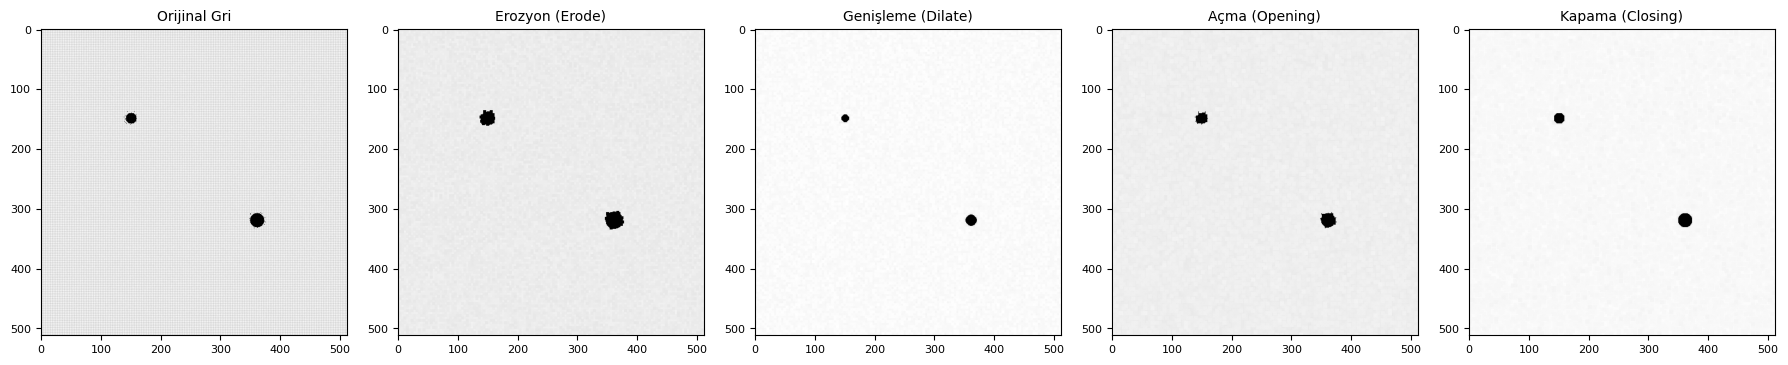

In [2]:
import sys
PROJECT_ROOT = CURRENT_DIR.parent.parent if CURRENT_DIR.name == "mini_project" else (CURRENT_DIR.parent if CURRENT_DIR.name == "day11" else CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day11.mini_project.src.morphology_engine import MorphologyEngine

engine = MorphologyEngine(kernel_size=5)

hole_path = FIXTURES_DIR / "carpet_defect_hole_puncture.png"
raw_data = np.fromfile(str(hole_path), dtype=np.uint8)
img_bgr = cv2.imdecode(raw_data, cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

eroded = engine.erode(gray)
dilated = engine.dilate(gray)
opened = engine.opening(gray)
closed = engine.closing(gray)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
titles = ["Orijinal Gri", "Erozyon (Erode)", "Genişleme (Dilate)", "Açma (Opening)", "Kapama (Closing)"]
images = [gray, eroded, dilated, opened, closed]

for ax, t, im in zip(axes, titles, images):
    ax.imshow(im, cmap="gray")
    ax.set_title(t, fontsize=10)
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

## 3. Artık Dönüşümleri (White Top-Hat & Black Top-Hat) ile Kusur İzolasyonu
Arka plan doku dalgalanmalarını filtreleyip parlak iplik topaklarını (WTH) ve koyu delik/yağ lekelerini (BTH) izole etme:

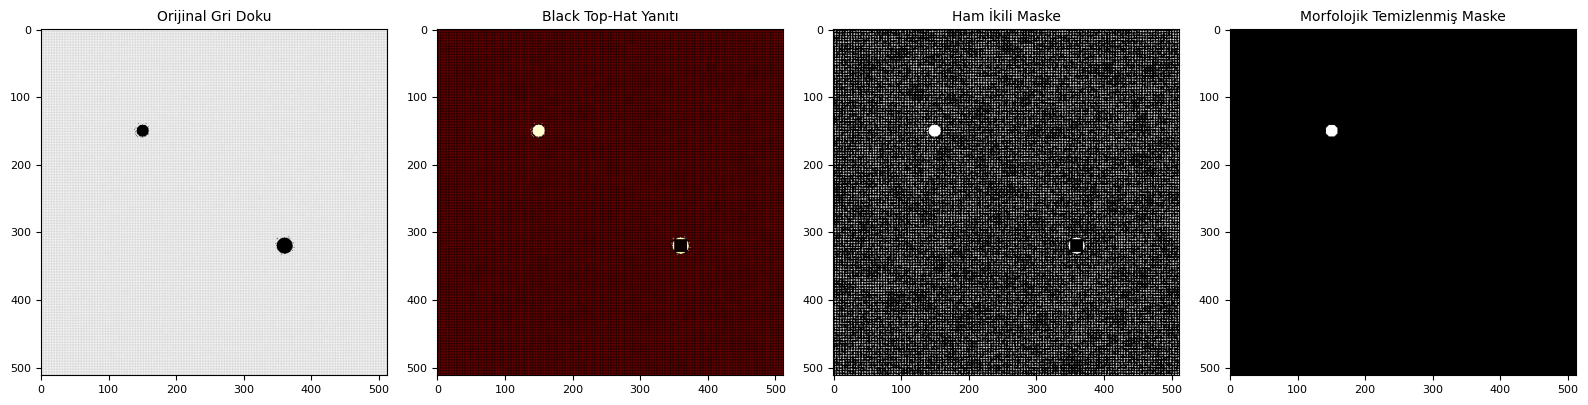

In [3]:
engine_large = MorphologyEngine(kernel_size=15)
wth = engine_large.white_tophat(gray)
bth = engine_large.black_tophat(gray)

_, mask_bth = cv2.threshold(bth, 25, 255, cv2.THRESH_BINARY)
clean_engine = MorphologyEngine(kernel_size=3)
mask_clean = clean_engine.opening(mask_bth)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Orijinal Gri Doku", fontsize=10)
axes[1].imshow(bth, cmap="hot")
axes[1].set_title("Black Top-Hat Yanıtı", fontsize=10)
axes[2].imshow(mask_bth, cmap="gray")
axes[2].set_title("Ham İkili Maske", fontsize=10)
axes[3].imshow(mask_clean, cmap="gray")
axes[3].set_title("Morfolojik Temizlenmiş Maske", fontsize=10)

for ax in axes:
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

## 4. Yönlü Çekirdekler ile İplik Yönü (Atkı / Çözgü) Analizi
Yatay atkı iplik kırıklarını köprülemek için dikey çekirdek (1x19), dikey çözgü kırıklarını yakalamak için yatay çekirdek (19x1) kullanılır.

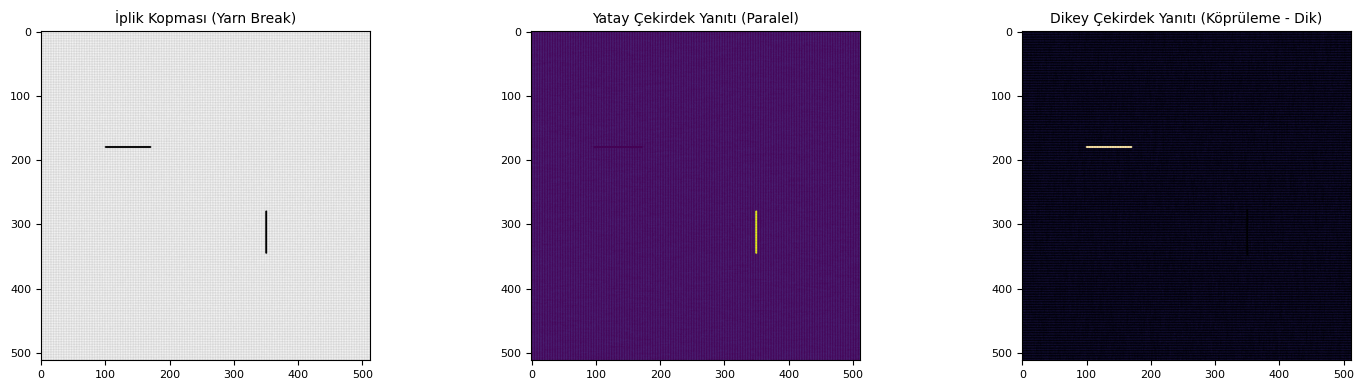

In [4]:
yarn_path = FIXTURES_DIR / "carpet_defect_yarn_break.png"
raw_yarn = np.fromfile(str(yarn_path), dtype=np.uint8)
yarn_bgr = cv2.imdecode(raw_yarn, cv2.IMREAD_COLOR)
gray_yarn = cv2.cvtColor(yarn_bgr, cv2.COLOR_BGR2GRAY)

k_horiz = MorphologyEngine.get_directional_kernel("horizontal", length=19, thickness=1)
k_vert = MorphologyEngine.get_directional_kernel("vertical", length=19, thickness=1)

bth_h = cv2.morphologyEx(gray_yarn, cv2.MORPH_BLACKHAT, k_horiz)
bth_v = cv2.morphologyEx(gray_yarn, cv2.MORPH_BLACKHAT, k_vert)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(gray_yarn, cmap="gray")
axes[0].set_title("İplik Kopması (Yarn Break)", fontsize=10)
axes[1].imshow(bth_h, cmap="viridis")
axes[1].set_title("Yatay Çekirdek Yanıtı (Paralel)", fontsize=10)
axes[2].imshow(bth_v, cmap="magma")
axes[2].set_title("Dikey Çekirdek Yanıtı (Köprüleme - Dik)", fontsize=10)

for ax in axes:
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

## 5. Uçtan Uca Halı Kusur Tespit Raporu ve Metrik Tablosu
`CarpetDefectDetector` ile tam denetim gerçekleştirilerek tespit edilen kusurların alan, geometrik oranlar, centroid ve rulo kalite derecesi (RollDecision) raporlanır.

In [5]:
import pandas as pd
from IPython.display import display
from day11.mini_project.src.defect_detector import CarpetDefectDetector

detector = CarpetDefectDetector()

records = []
for title, fpath in image_files[:4]:
    raw_d = np.fromfile(str(fpath), dtype=np.uint8)
    img_bgr = cv2.imdecode(raw_d, cv2.IMREAD_COLOR)
    report, _ = detector.inspect(img_bgr, image_path=title)
    
    for d in report.defects:
        b = d.bbox
        records.append({
            "Dosya": title,
            "Kusur Tipi": d.defect_type.value,
            "Önem Derecesi": d.severity.value,
            "Güven": f"%{d.confidence*100:.1f}",
            "Alan (px)": f"{b.area:.0f}",
            "En/Boy Oranı": f"{b.aspect_ratio:.2f}",
            "Merkez (x,y)": f"({b.centroid[0]:.1f}, {b.centroid[1]:.1f})",
            "Rulo Kararı": report.roll_decision.value
        })

df = pd.DataFrame(records)
print(f"Toplam Tespit Edilen Kusur Adedi: {len(df)}")
display(df)

Toplam Tespit Edilen Kusur Adedi: 6


,Dosya,Kusur Tipi,Önem Derecesi,Güven,Alan (px),En/Boy Oranı,"Merkez (x,y)",Rulo Kararı
0,carpet_defect_yarn_break.png,YARN_BREAK_WARP,MAJOR,%94.0,267,13.60,"(350.0, 312.4)",PASS
1,carpet_defect_yarn_break.png,YARN_BREAK_WEFT,MAJOR,%94.0,288,14.60,"(135.0, 180.0)",PASS
2,carpet_defect_hole_puncture.png,OIL_STAIN,CRITICAL,%96.3,508,1.00,"(360.0, 319.8)",REJECT
3,carpet_defect_hole_puncture.png,OIL_STAIN,MAJOR,%97.1,304,1.05,"(149.8, 150.2)",REJECT
4,carpet_defect_oil_slub.png,SLUB_KNOT,MAJOR,%77.6,206,1.12,"(380.3, 180.2)",REJECT
5,carpet_defect_oil_slub.png,OIL_STAIN,CRITICAL,%82.5,1013,1.21,"(200.0, 219.9)",REJECT
